In [1]:
import sys
sys.path.append('/data/Aldhani/cv_fields/code/decode/')
sys.path.append('/data/Aldhani/cv_fields/code/')
sys.path.append('/data/Aldhani/cv_fields/code/smallholder-fields/code/')

In [2]:
import os
import glob
import time

import numpy as np
#np.bool = np.bool_ # reassigning deprecated np.bool for mxnet
import pandas as pd

import cv2
import higra as hg

from osgeo import gdal
from osgeo import ogr
from osgeo import osr

import matplotlib.pyplot as plt

In [3]:
import mxnet as mx
from mxnet import nd, gpu, gluon, autograd, npx, image
from mxnet.gluon.data import DataLoader
from mxnet.gluon.data.vision import transforms
from mxnet.gluon.loss import Loss

In [4]:
from decode.FracTAL_ResUNet.nn.loss.mtsk_loss import *
from decode.FracTAL_ResUNet.models.heads.head_cmtsk import *
from decode.FracTAL_ResUNet.models.semanticsegmentation.FracTAL_ResUNet_features import *
from decode.FracTAL_ResUNet.models.semanticsegmentation.FracTAL_ResUNet import FracTAL_ResUNet_cmtsk

from helpers_model import *

In [5]:
os.getcwd()

'/data/Aldhani/cv_fields/code/smallholder-fields/code'

In [6]:
# download pretrained model from airbus france india dataset (Wang et al. 2022)
import urllib.request
os.makedirs("../model", exist_ok=True)
if not os.path.exists("../model/airbus_france_india.params"):
    urllib.request.urlretrieve(
        "https://zenodo.org/records/7315090/files/india_Airbus_SPOT_model.params?download=1",
        "../model/airbus_france_india.params")

In [7]:
# path to pre-trained model
model = '../model/airbus_france_india.params'

# model hyperparams
depth=6
NClasses=1
nfilters_init=32
linear_norm = False
#norm = 'none'

# load params
net = FracTAL_ResUNet_cmtsk(nfilters_init=nfilters_init, NClasses=NClasses,depth=depth)
net.load_parameters(model)
net.collect_params().reset_ctx(gpu(0))


depth:= 0, nfilters: 32, nheads::8, widths::1
depth:= 1, nfilters: 64, nheads::16, widths::1
depth:= 2, nfilters: 128, nheads::32, widths::1
depth:= 3, nfilters: 256, nheads::64, widths::1
depth:= 4, nfilters: 512, nheads::128, widths::1
depth:= 5, nfilters: 1024, nheads::256, widths::1
depth:= 6, nfilters: 512, nheads::256, widths::1
depth:= 7, nfilters: 256, nheads::128, widths::1
depth:= 8, nfilters: 128, nheads::64, widths::1
depth:= 9, nfilters: 64, nheads::32, widths::1
depth:= 10, nfilters: 32, nheads::16, widths::1


[13:45:15] /work/mxnet/src/base.cc:79: cuDNN lib mismatch: linked-against version 8600 != compiled-against version 8500.  Set MXNET_CUDNN_LIB_CHECKING=0 to quiet this warning.


In [8]:
############################################
# pseudo-label selection thresholds

############
# fields

# percentile instance-level semantic uncertainty (SemC)
apply_p_scor = True
p_scor = 98

# percentile instance-level instance uncertainty (InsC)
apply_p_inst = False
p_inst = 75

# absolute instance-level semantic uncertainty (SemC)
apply_a_scor = False
a_scor = 0.90

# size threshold (pixels)
t_size = 500
apply_t_size = False

############
# non-crop

# percentile instance-level semantic uncertainty (SemC)
apply_p_ncrp = True
p_ncrp = 10

# percentile instance-level instance uncertainty (InsC)
apply_p_inlw = False
p_inlw = 25

# absolute instance-level semantic uncertainty (SemC)
apply_a_ncrp = False
a_ncrp = 0.75

In [9]:
############################################
# instance generation thresholds
# define probability threshold of field extent and boundary
# for hierarchical watershed segmentation (see Waldner et al. 2021)
t_ext=0.4
t_bound=0.2


In [10]:
############################################
# define folder containing input images
# search input files based on extension

img_path = '../sample_data/'
in_files = sorted(glob.glob(img_path + '*.tif'))
print(in_files)

# write pseudo labels as *.tif to output folder
write=True
if write:
  # create output folder
  out_path = '../labels/'
  os.makedirs(out_path, exist_ok=True)

# create plots?
plot=True

['../sample_data/mozambique_tile_32636_00020_-0281_20230917.tif']


../sample_data/mozambique_tile_32636_00020_-0281_20230917.tif
field instances: 914
pseudo labels generated: 20
../labels//mozambique_tile_32636_00020_-0281_20230917_mtsk.tif


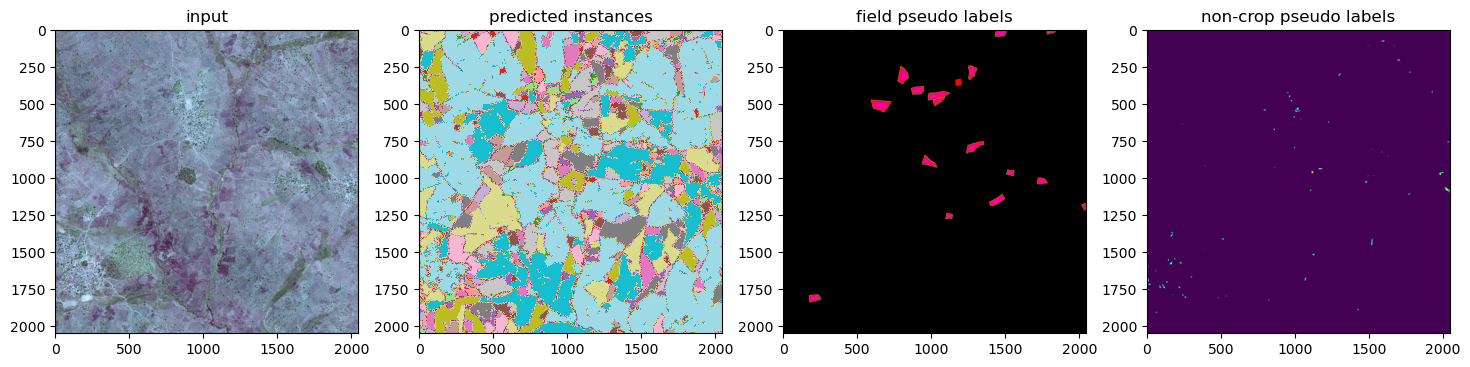

32.88845157623291


In [12]:
# run pseudo-label generation for subset of sample image

for iter, in_file in enumerate(in_files):

  tic = time.time()
  ###################################################################
  # open & predict
  print(in_file)

  input = open_tif_rgb(in_file)
  in_tns = input[None,:,:,:]

  preds = net(in_tns)
  
  ###################################################################
  # create instances
  example_extent = np.squeeze(preds[0]).asnumpy()
  example_boundary = np.squeeze(preds[1]).asnumpy()
  inst = InstSegm(example_extent, example_boundary, t_ext=t_ext, t_bound=t_bound)

  ###################################################################
  # copy array
  inst_full = np.copy(inst)
  inst_ncrp = np.copy(inst)

  ###################################################################
  # get unique ids
  iids = np.unique(inst)
  iids = iids[(iids!=0)]
  print('field instances: '+ str(len(iids)))

  ###################################################################
  # instance level scores
  instance_score = np.array([np.nanmedian(example_extent[(inst==iid)]) for iid in iids])
  bounds = example_boundary*get_boundary(inst, kernel_size=(1,1))
  bounds[bounds==0] = np.nan
  instance_uncert = np.array([np.nanmedian(bounds[(inst==id)]) for id in iids])
  instance_size = np.array([len(inst[(inst==id)]) for id in iids])

  ###################################################################
  # pseudo label selection

  ###################################################################
  # select field instances based on semantic and instance uncertainty
  fids = []
  if apply_p_scor:
    t_scor = np.nanpercentile(instance_score, p_scor) #percentile instance-level semantic uncertainty
    rmv = np.array([iid for i, iid in enumerate(iids) if (instance_score[i] < t_scor)])
    fids = np.append(fids, rmv, axis=0)

  if apply_p_inst:
    t_inst = np.nanpercentile(instance_uncert, p_inst) #percentile instance-level instance uncertainty
    rmv = np.array([iid for i, iid in enumerate(iids) if (instance_score[i] < t_inst)])
    fids = np.append(fids, rmv, axis=0)

  if apply_a_scor:
    rmv = np.array([iid for i, iid in enumerate(iids) if (instance_score[i] < a_scor)])

  ###################################################################
  # select non cropland instances based on semantic and instance uncertainty
  cids = []
  if apply_p_ncrp:
    t_ncrp = np.nanpercentile(instance_score, p_ncrp) #percentile instance-level semantic uncertainty for non-crop instances
    rmv = np.array([iid for i, iid in enumerate(iids) if (instance_score[i] > t_ncrp)])
    cids = np.append(cids, rmv, axis=0)

  if apply_p_inlw:
    t_inlw = np.nanpercentile(instance_uncert, p_inlw) #percentile instance-level instance uncertainty for non-crop instances
    rmv = np.array([iid for i, iid in enumerate(iids) if (instance_uncert[i] > t_inlw)])

  if apply_a_ncrp:
    rmv = np.array([iid for i, iid in enumerate(iids) if (instance_score[i] > a_ncrp)])

  ###################################################################
  # set non-matching instances to
  for fid in fids:
    inst[(inst==fid)] = 0

  for cid in cids:
    inst_ncrp[(inst_ncrp==cid)] = 0
  inst_ncrp[(inst_ncrp>0)] = 1.
  inst_ncrp[(inst_ncrp<0)] = 0.

  if np.sum(inst>0):
    print('pseudo labels generated: ' + str(len(np.unique(inst)-1)))

    edge = get_boundary(inst)
    crop = (inst>0).astype(np.uint8)
    dist = get_distance(inst.astype(np.uint8))
    dist[np.isnan(dist)] = 0
    label = np.stack([crop, edge, dist, inst_ncrp])

    # map instances to better range for plotting
    unique_instances = sorted(np.unique(inst_full))
    min_instance = unique_instances[1]
    max_instance = unique_instances[-1]
    n_instances = len(unique_instances)
    instance_map = {x: i for i, x in enumerate(unique_instances)}
    def map_values(x):
        return instance_map[x]
    inst_full = np.array(list(map(map_values, inst_full.flatten()))).reshape(inst_full.shape[0], inst_full.shape[1])

    if write:

      if not os.path.exists(out_path): os.mkdir(out_path)

      outfile_rast = out_path+'/'+os.path.basename(in_file)[:-4]+'_mtsk.tif'
      print(outfile_rast)

      if not os.path.isfile(outfile_rast):
        mds = create_mem_ds(in_file, 4)

        for b in range(4):
          bnd = np.squeeze(label[b])
          mds.GetRasterBand(b+1).WriteArray(bnd)

        copy_mem_ds(outfile_rast, mds)
        mds = None

    if plot:
      fig, ax = plt.subplots(1, 4, figsize=(18, 12))

      ax[0].imshow(np.moveaxis(np.squeeze(in_tns).asnumpy(), 0,2)/255)
      ax[0].set_title('input')

      ax[1].imshow(inst_full, vmin=0, vmax=n_instances+1, cmap='tab20')
      ax[1].set_title('predicted instances')

      ax[2].imshow(np.moveaxis(label[0:3,:,:], 0, 2))
      ax[2].set_title('field pseudo labels')

      ax[3].imshow(inst_ncrp)
      ax[3].set_title('non-crop pseudo labels')

      plt.show()

      print(time.time()-tic)
  else: print('no labels found')